In [ ]:
!gdown 1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw

Downloading...
From (original): https://drive.google.com/uc?id=1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw
From (redirected): https://drive.google.com/uc?id=1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw&confirm=t&uuid=74603710-483d-432a-81c6-4f2b07ed6bb7
To: /content/data.zip
100% 363M/363M [00:06<00:00, 56.3MB/s]


In [ ]:
!unzip -q /content/data.zip

In [ ]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': True,
          'axes.edgecolor': '.8',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': True,
          'axes.grid.axis': 'both',
         

In [ ]:
DATA_ROOT = Path("/content/")

TRAIN_DIR = DATA_ROOT / "seg_train/seg_train"
TEST_DIR = DATA_ROOT / "seg_test/seg_test"
PRED_DIR = DATA_ROOT / "seg_pred/seg_pred"

print("TRAIN_DIR exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("TEST_DIR exists :", TEST_DIR.exists(), TEST_DIR)
print("PRED_DIR exists :", PRED_DIR.exists(), PRED_DIR)

TRAIN_DIR exists: True /content/seg_train/seg_train
TEST_DIR exists : True /content/seg_test/seg_test
PRED_DIR exists : True /content/seg_pred/seg_pred


In [ ]:
def collect_image_paths(split_dir, split_name, has_class_subfolders=True):
    records = []

    if not split_dir.exists():
        print(f"[WARNING] Không tìm thấy thư mục: {split_dir}")
        return pd.DataFrame(columns=["split", "label", "file_path", "file_name"])

    if has_class_subfolders:
        class_dirs = [d for d in split_dir.iterdir() if d.is_dir()]
        for class_dir in sorted(class_dirs):
            label = class_dir.name
            for img_path in class_dir.glob("*"):
                if img_path.is_file():
                    records.append({
                        "split": split_name,
                        "label": label,
                        "file_path": str(img_path),
                        "file_name": img_path.name
                    })
    else:
        for img_path in split_dir.glob("*"):
            if img_path.is_file():
                records.append({
                    "split": split_name,
                    "label": "unknown",
                    "file_path": str(img_path),
                    "file_name": img_path.name
                })

    return pd.DataFrame(records)

In [ ]:
df_train = collect_image_paths(TRAIN_DIR, "train", has_class_subfolders=True)
df_test  = collect_image_paths(TEST_DIR, "test", has_class_subfolders=True)
df_pred  = collect_image_paths(PRED_DIR, "pred", has_class_subfolders=False)

df_all = pd.concat([df_train, df_test, df_pred], ignore_index=True)

print("Tổng số ảnh:", len(df_all))
display(df_all.head())

Tổng số ảnh: 24335


,split,label,file_path,file_name
0,train,buildings,/content/seg_train/seg_train/buildings/5617.jpg,5617.jpg
1,train,buildings,/content/seg_train/seg_train/buildings/6143.jpg,6143.jpg
2,train,buildings,/content/seg_train/seg_train/buildings/7138.jpg,7138.jpg
3,train,buildings,/content/seg_train/seg_train/buildings/15331.jpg,15331.jpg
4,train,buildings,/content/seg_train/seg_train/buildings/17416.jpg,17416.jpg


In [ ]:
print("Số ảnh theo split:")
display(df_all["split"].value_counts().rename_axis("split").reset_index(name="count"))

print("\nSố lớp trong train:")
display(df_train["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("\nSố lớp trong test:")
display(df_test["label"].value_counts().rename_axis("label").reset_index(name="count"))

Số ảnh theo split:


,split,count
0,train,14034
1,pred,7301
2,test,3000



Số lớp trong train:


,label,count
0,mountain,2512
1,glacier,2404
2,street,2382
3,sea,2274
4,forest,2271
5,buildings,2191



Số lớp trong test:


,label,count
0,glacier,553
1,mountain,525
2,sea,510
3,street,501
4,forest,474
5,buildings,437


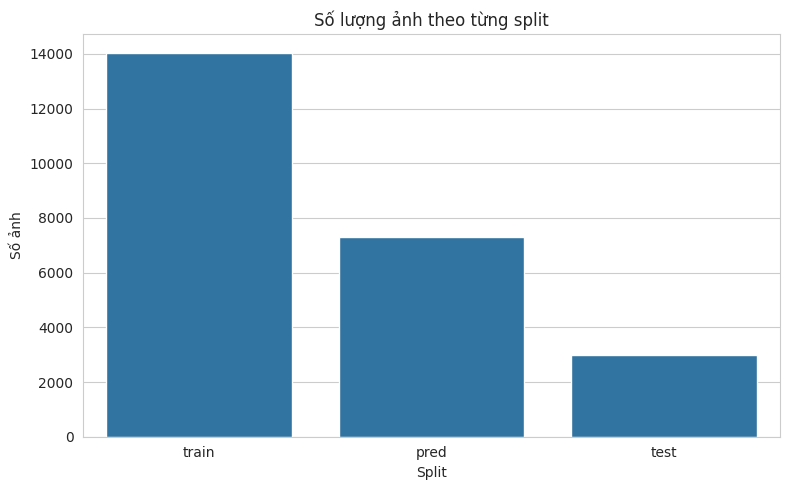

In [ ]:
split_counts = df_all["split"].value_counts().reset_index()
split_counts.columns = ["split", "count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=split_counts, x="split", y="count")
plt.title("Số lượng ảnh theo từng split")
plt.xlabel("Split")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()

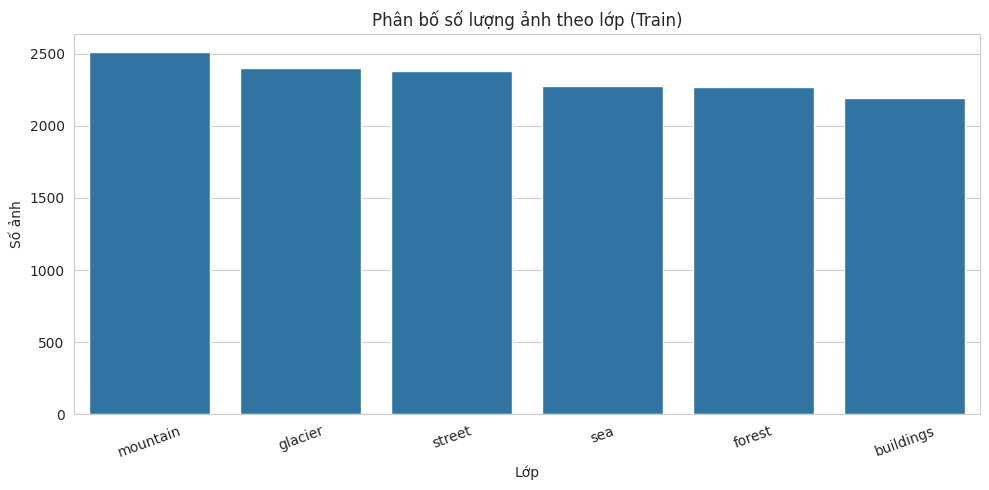

In [ ]:
train_class_counts = df_train["label"].value_counts().reset_index()
train_class_counts.columns = ["label", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=train_class_counts, x="label", y="count")
plt.title("Phân bố số lượng ảnh theo lớp (Train)")
plt.xlabel("Lớp")
plt.ylabel("Số ảnh")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
def get_image_info(img_path):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode, None
    except (UnidentifiedImageError, OSError) as e:
        return None, None, None, str(e)

In [ ]:
sample_df = df_all.copy()

widths = []
heights = []
modes = []
errors = []

for path in tqdm(sample_df["file_path"], desc="Đang đọc metadata ảnh"):
    w, h, m, err = get_image_info(path)
    widths.append(w)
    heights.append(h)
    modes.append(m)
    errors.append(err)

sample_df["width"] = widths
sample_df["height"] = heights
sample_df["mode"] = modes
sample_df["error"] = errors

Đang đọc metadata ảnh: 100%|██████████| 24335/24335 [00:03<00:00, 6136.12it/s]


In [ ]:
print("Số file lỗi:", sample_df["error"].notnull().sum())
display(sample_df[sample_df["error"].notnull()].head())

Số file lỗi: 0


,split,label,file_path,file_name,width,height,mode,error


In [ ]:
print("Các kích thước ảnh xuất hiện nhiều nhất:")
display(
    sample_df[["width", "height"]]
    .value_counts()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

Các kích thước ảnh xuất hiện nhiều nhất:


,width,height,count
0,150,150,24267
1,150,113,7
2,150,111,3
3,150,108,3
4,150,149,3
5,150,144,3
6,150,143,3
7,150,135,3
8,150,131,3
9,150,76,2


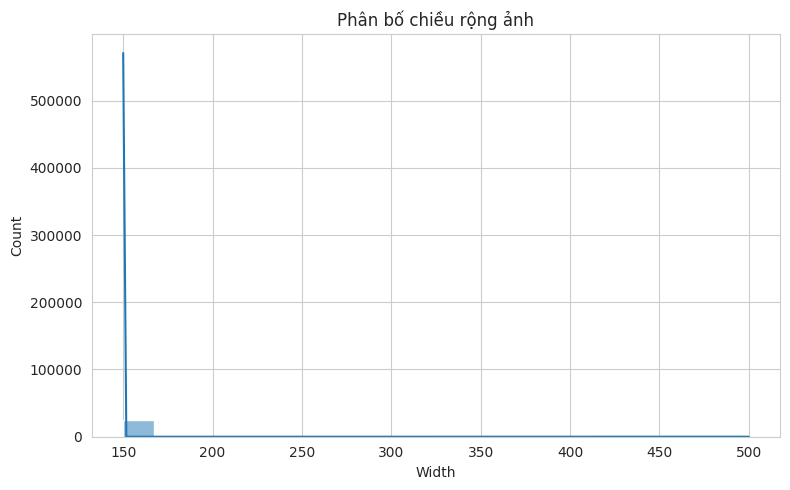

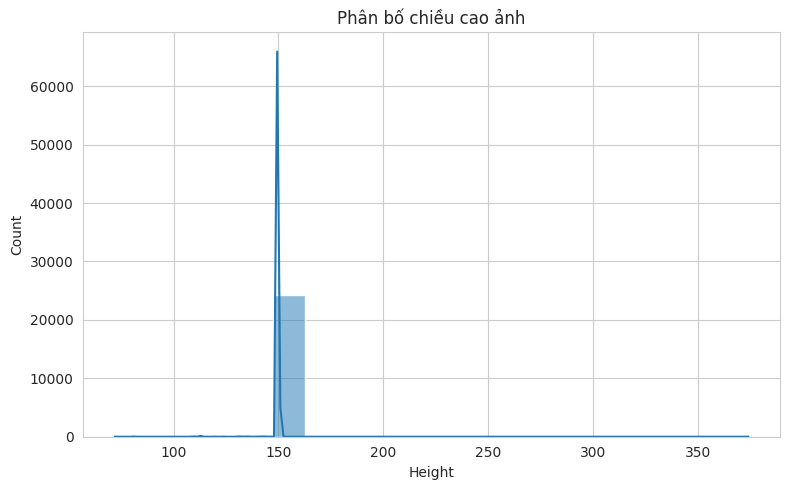

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(sample_df["width"].dropna(), bins=20, kde=True)
plt.title("Phân bố chiều rộng ảnh")
plt.xlabel("Width")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(sample_df["height"].dropna(), bins=20, kde=True)
plt.title("Phân bố chiều cao ảnh")
plt.xlabel("Height")
plt.tight_layout()
plt.show()

In [ ]:
print("Phân bố mode màu:")
display(sample_df["mode"].value_counts(dropna=False).rename_axis("mode").reset_index(name="count"))

Phân bố mode màu:


,mode,count
0,RGB,24335


In [ ]:
def show_sample_images(df, split="train", samples_per_class=5):
    subset = df[df["split"] == split].copy()
    classes = sorted(subset["label"].unique())

    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(3*samples_per_class, 3*len(classes)))

    if len(classes) == 1:
        axes = np.array([axes])

    for i, label in enumerate(classes):
        class_samples = subset[subset["label"] == label].sample(
            n=min(samples_per_class, len(subset[subset["label"] == label])),
            random_state=42
        )

        for j in range(samples_per_class):
            ax = axes[i, j]
            ax.axis("off")

            if j < len(class_samples):
                img_path = class_samples.iloc[j]["file_path"]
                img = Image.open(img_path)
                ax.imshow(img)
                if j == 0:
                    ax.set_title(label, fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
show_sample_images(df_all, split="train", samples_per_class=5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print("Số file_path trùng nhau:", df_all["file_path"].duplicated().sum())
print("Số file_name trùng nhau :", df_all["file_name"].duplicated().sum())

Số file_path trùng nhau: 0
Số file_name trùng nhau : 0


In [ ]:
import hashlib


# =========================
# KIỂM TRA ẢNH TRÙNG LẶP
# =========================
# Yêu cầu trước đó:
# - df_all phải có cột: file_path
# - nếu đã khai báo DATA_ROOT ở cell trước thì sẽ dùng để tạo đường dẫn tương đối đẹp hơn

def get_file_md5(file_path, chunk_size=8192):
    md5 = hashlib.md5()
    try:
        with open(file_path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                md5.update(chunk)
        return md5.hexdigest()
    except Exception:
        return None

# Copy dataframe để không làm ảnh hưởng df_all gốc
df_dup = df_all.copy()

# Tạo thông tin thư mục chứa file
def get_folder_rel(path_str):
    p = Path(path_str).parent
    try:
        return str(p.relative_to(DATA_ROOT))
    except:
        return str(p)

df_dup["folder"] = df_dup["file_path"].apply(get_folder_rel)
df_dup["file_name"] = df_dup["file_path"].apply(lambda x: Path(x).name)

# Tính hash cho từng ảnh
tqdm.pandas(desc="Hashing images")
df_dup["file_hash"] = df_dup["file_path"].progress_apply(get_file_md5)

# Bỏ file lỗi / file không hash được
df_valid = df_dup.dropna(subset=["file_hash"]).copy()

# -------------------------------------------------
# 1) ẢNH TRÙNG TRONG CÙNG 1 THƯ MỤC
# -------------------------------------------------
same_folder_keys = (
    df_valid.groupby(["folder", "file_hash"])
    .size()
    .reset_index(name="count")
)
same_folder_keys = same_folder_keys[same_folder_keys["count"] > 1]

same_folder_duplicates = (
    df_valid.merge(same_folder_keys[["folder", "file_hash", "count"]],
                   on=["folder", "file_hash"],
                   how="inner")
    .sort_values(["folder", "file_hash", "file_name"])
)

# -------------------------------------------------
# 2) ẢNH TRÙNG GIỮA CÁC THƯ MỤC KHÁC NHAU
# -------------------------------------------------
cross_folder_keys = (
    df_valid.groupby("file_hash")["folder"]
    .nunique()
    .reset_index(name="n_folders")
)
cross_folder_keys = cross_folder_keys[cross_folder_keys["n_folders"] > 1]

cross_folder_duplicates = (
    df_valid.merge(cross_folder_keys, on="file_hash", how="inner")
    .sort_values(["file_hash", "folder", "file_name"])
)

# -------------------------------------------------
# IN KẾT QUẢ TÓM TẮT
# -------------------------------------------------
print("=" * 60)
print("TỔNG KẾT KIỂM TRA ẢNH TRÙNG")
print("=" * 60)
print(f"Tổng số ảnh hợp lệ để kiểm tra: {len(df_valid)}")
print(f"Số nhóm ảnh trùng trong cùng 1 thư mục: {same_folder_keys.shape[0]}")
print(f"Số file nằm trong các nhóm trùng cùng thư mục: {same_folder_duplicates.shape[0]}")
print(f"Số hash xuất hiện ở nhiều thư mục khác nhau: {cross_folder_keys.shape[0]}")
print(f"Số file nằm trong các nhóm trùng khác thư mục: {cross_folder_duplicates.shape[0]}")

print("\n" + "=" * 60)
print("MẪU ẢNH TRÙNG TRONG CÙNG 1 THƯ MỤC")
print("=" * 60)
display(
    same_folder_duplicates[
        ["folder", "file_name", "file_path", "file_hash", "count"]
    ].head(20)
)

print("\n" + "=" * 60)
print("MẪU ẢNH TRÙNG GIỮA CÁC THƯ MỤC KHÁC NHAU")
print("=" * 60)
display(
    cross_folder_duplicates[
        ["folder", "file_name", "file_path", "file_hash", "n_folders"]
    ].head(20)
)



Hashing images:   0%|          | 0/24335 [00:00<?, ?it/s]

TỔNG KẾT KIỂM TRA ẢNH TRÙNG
Tổng số ảnh hợp lệ để kiểm tra: 24335
Số nhóm ảnh trùng trong cùng 1 thư mục: 10
Số file nằm trong các nhóm trùng cùng thư mục: 20
Số hash xuất hiện ở nhiều thư mục khác nhau: 37
Số file nằm trong các nhóm trùng khác thư mục: 74

MẪU ẢNH TRÙNG TRONG CÙNG 1 THƯ MỤC


,folder,file_name,file_path,file_hash,count
12,seg_pred/seg_pred,19269.jpg,/content/seg_pred/seg_pred/19269.jpg,85522f7eb2b8456d58ef0608803370ab,2
11,seg_pred/seg_pred,7484.jpg,/content/seg_pred/seg_pred/7484.jpg,85522f7eb2b8456d58ef0608803370ab,2
15,seg_pred/seg_pred,16921.jpg,/content/seg_pred/seg_pred/16921.jpg,ae7692e2e14fb4c5d8e6c22681cc1bd4,2
16,seg_pred/seg_pred,7486.jpg,/content/seg_pred/seg_pred/7486.jpg,ae7692e2e14fb4c5d8e6c22681cc1bd4,2
10,seg_pred/seg_pred,21223.jpg,/content/seg_pred/seg_pred/21223.jpg,c657b68d50d6b70824d34a516c0b2f02,2
18,seg_pred/seg_pred,3970.jpg,/content/seg_pred/seg_pred/3970.jpg,c657b68d50d6b70824d34a516c0b2f02,2
14,seg_pred/seg_pred,18879.jpg,/content/seg_pred/seg_pred/18879.jpg,ced5388ae2040c2d99c801e930030714,2
19,seg_pred/seg_pred,5953.jpg,/content/seg_pred/seg_pred/5953.jpg,ced5388ae2040c2d99c801e930030714,2
17,seg_pred/seg_pred,18039.jpg,/content/seg_pred/seg_pred/18039.jpg,d35a5c3cb45d3e980a7d1bfb5dce0136,2
13,seg_pred/seg_pred,18760.jpg,/content/seg_pred/seg_pred/18760.jpg,d35a5c3cb45d3e980a7d1bfb5dce0136,2



MẪU ẢNH TRÙNG GIỮA CÁC THƯ MỤC KHÁC NHAU


,folder,file_name,file_path,file_hash,n_folders
72,seg_pred/seg_pred,5229.jpg,/content/seg_pred/seg_pred/5229.jpg,015d83aa90a3fac620bd1fd595a55a95,2
32,seg_train/seg_train/sea,18707.jpg,/content/seg_train/seg_train/sea/18707.jpg,015d83aa90a3fac620bd1fd595a55a95,2
10,seg_train/seg_train/glacier,8191.jpg,/content/seg_train/seg_train/glacier/8191.jpg,0e1ff2651ce5f2b2b435adc3704f5da8,2
15,seg_train/seg_train/mountain,16696.jpg,/content/seg_train/seg_train/mountain/16696.jpg,0e1ff2651ce5f2b2b435adc3704f5da8,2
55,seg_pred/seg_pred,17644.jpg,/content/seg_pred/seg_pred/17644.jpg,0f828d0b42199af7df469e9eada73f32,2
5,seg_train/seg_train/buildings,4000.jpg,/content/seg_train/seg_train/buildings/4000.jpg,0f828d0b42199af7df469e9eada73f32,2
52,seg_pred/seg_pred,13465.jpg,/content/seg_pred/seg_pred/13465.jpg,157bfa252f9b4f5b8a57a7e815152c02,2
24,seg_train/seg_train/mountain,10214.jpg,/content/seg_train/seg_train/mountain/10214.jpg,157bfa252f9b4f5b8a57a7e815152c02,2
50,seg_pred/seg_pred,10873.jpg,/content/seg_pred/seg_pred/10873.jpg,1f8f62f6157d44cc77896ec394655c9c,2
8,seg_train/seg_train/forest,10721.jpg,/content/seg_train/seg_train/forest/10721.jpg,1f8f62f6157d44cc77896ec394655c9c,2


Tổng số nhóm ảnh trùng trong cùng 1 thư mục: 10
Nhóm 1
Thư mục : seg_pred/seg_pred
Hash    : 85522f7eb2b8456d58ef0608803370ab
Số ảnh  : 2


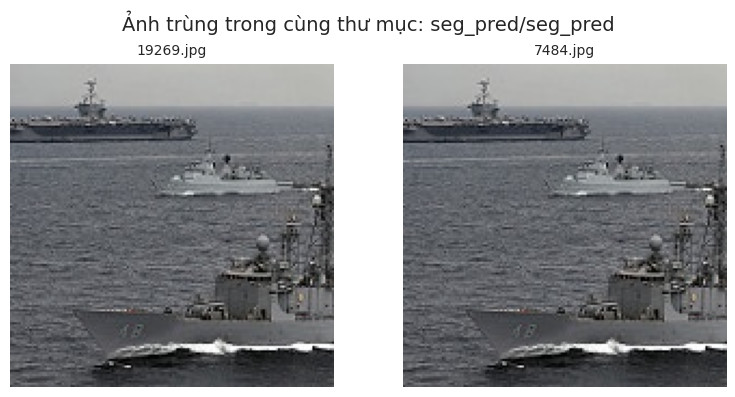

Nhóm 2
Thư mục : seg_pred/seg_pred
Hash    : ae7692e2e14fb4c5d8e6c22681cc1bd4
Số ảnh  : 2


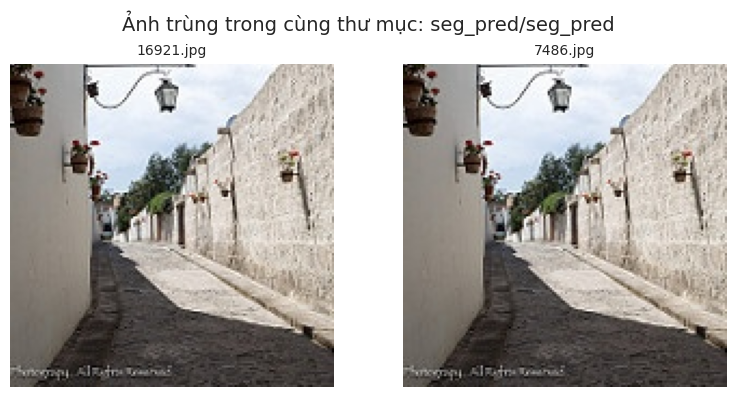

Nhóm 3
Thư mục : seg_pred/seg_pred
Hash    : c657b68d50d6b70824d34a516c0b2f02
Số ảnh  : 2


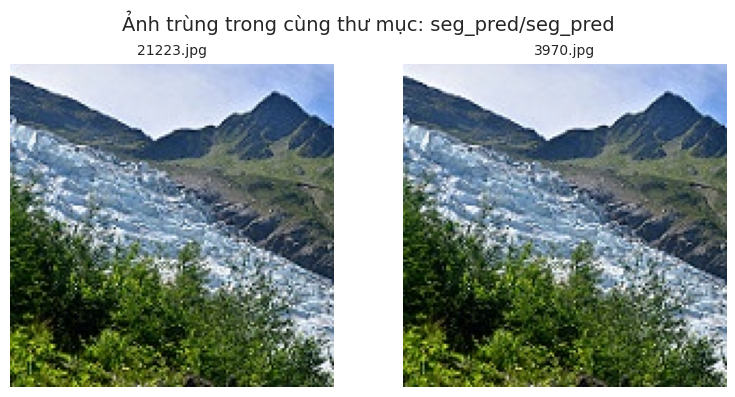

Nhóm 4
Thư mục : seg_pred/seg_pred
Hash    : ced5388ae2040c2d99c801e930030714
Số ảnh  : 2


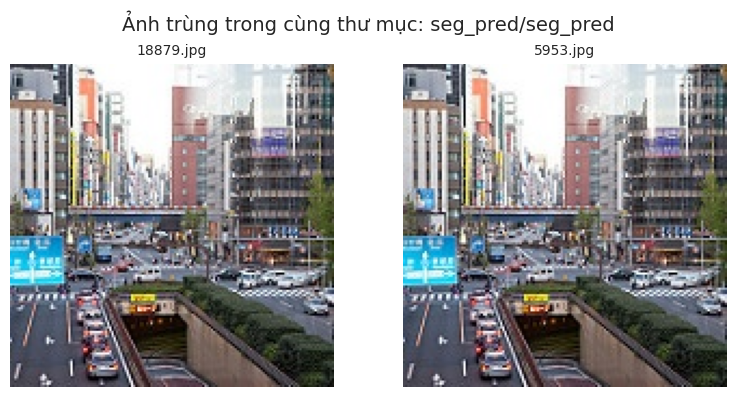

Nhóm 5
Thư mục : seg_pred/seg_pred
Hash    : d35a5c3cb45d3e980a7d1bfb5dce0136
Số ảnh  : 2


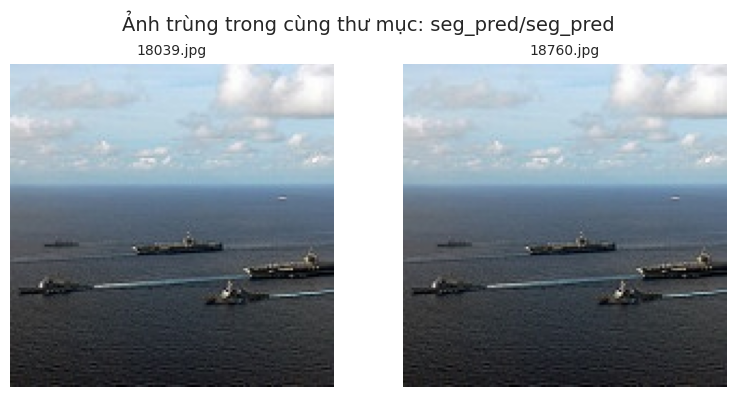

Nhóm 6
Thư mục : seg_train/seg_train/forest
Hash    : a687bd9f1e8ff567fb44e5ea081cb1ee
Số ảnh  : 2


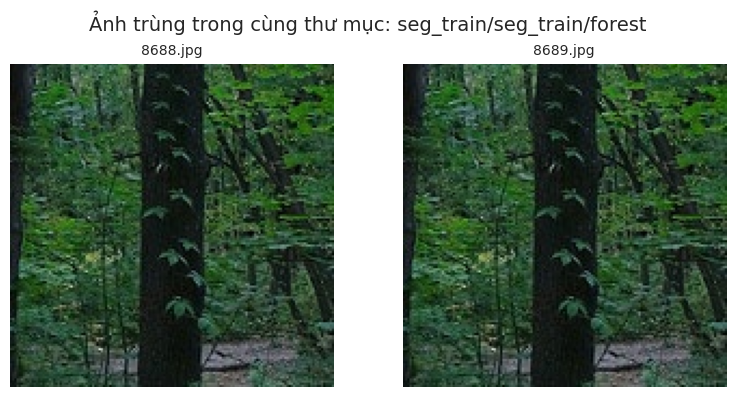

Nhóm 7
Thư mục : seg_train/seg_train/forest
Hash    : b1d681429db12d50c411d0dee7877a60
Số ảnh  : 2


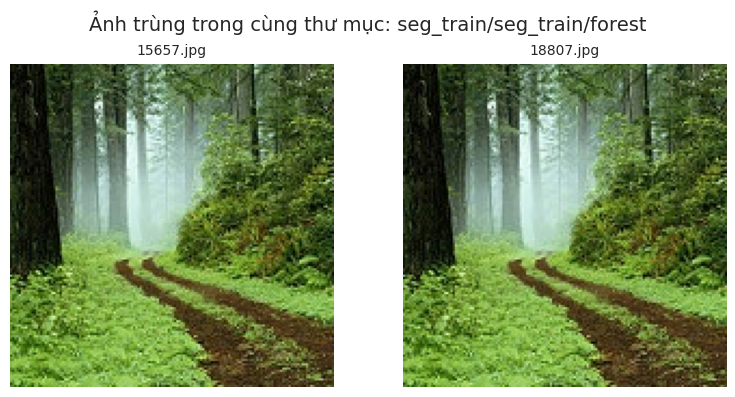

Nhóm 8
Thư mục : seg_train/seg_train/sea
Hash    : 0b425690368e341777a1d5ee3aef3e1e
Số ảnh  : 2


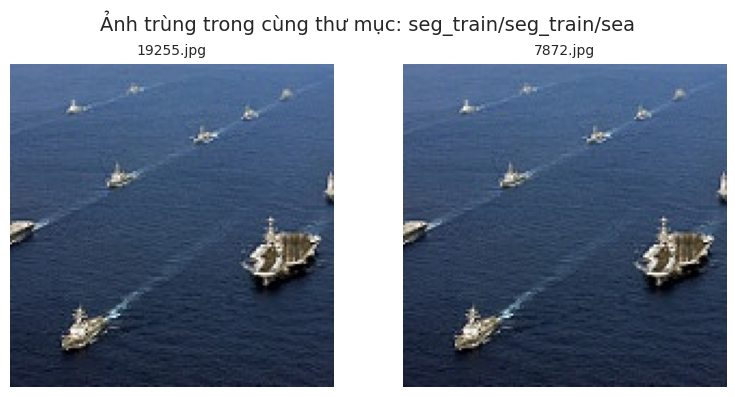

Nhóm 9
Thư mục : seg_train/seg_train/street
Hash    : 336ff282d3c3e4321e1a1629140a8548
Số ảnh  : 2


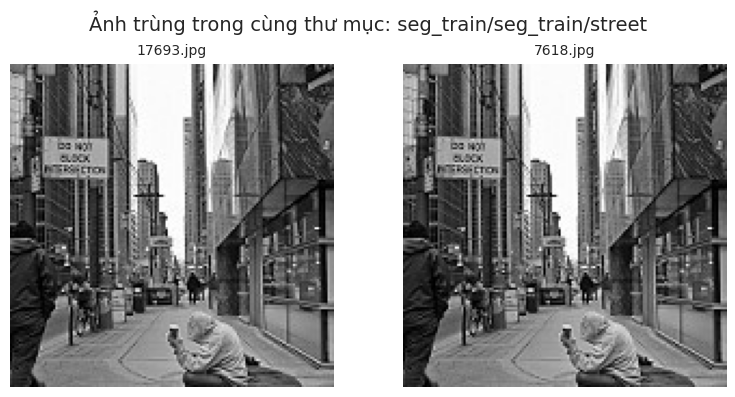

Nhóm 10
Thư mục : seg_train/seg_train/street
Hash    : a878cdfd9de29964fb3a84e8dacd7034
Số ảnh  : 2


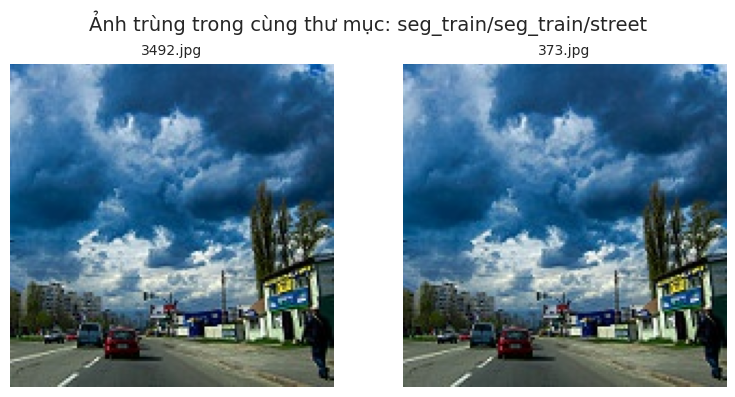

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from math import ceil

# ==============================
# HIỂN THỊ ẢNH TRÙNG CÙNG THƯ MỤC
# ==============================
# Yêu cầu:
# - same_folder_duplicates đã được tạo từ cell trước
# - có các cột: folder, file_path, file_name, file_hash

# Gom nhóm theo (folder, file_hash)
duplicate_groups = list(same_folder_duplicates.groupby(["folder", "file_hash"]))

print(f"Tổng số nhóm ảnh trùng trong cùng 1 thư mục: {len(duplicate_groups)}")

# Có thể đổi số nhóm muốn xem
max_groups_to_show = 10

for idx, ((folder, file_hash), group) in enumerate(duplicate_groups[:max_groups_to_show], start=1):
    n = len(group)
    cols = min(n, 4)
    rows = ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    print("=" * 80)
    print(f"Nhóm {idx}")
    print(f"Thư mục : {folder}")
    print(f"Hash    : {file_hash}")
    print(f"Số ảnh  : {n}")

    for ax, (_, row) in zip(axes, group.iterrows()):
        try:
            img = Image.open(row["file_path"]).convert("RGB")
            ax.imshow(img)
            ax.set_title(row["file_name"], fontsize=10)
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, f"Lỗi đọc ảnh\n{row['file_name']}", ha="center", va="center")
            ax.axis("off")

    # Tắt các ô thừa
    for ax in axes[len(group):]:
        ax.axis("off")

    plt.suptitle(f"Ảnh trùng trong cùng thư mục: {folder}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
def compute_mean_std(image_paths, sample_size=1000):
    if len(image_paths) > sample_size:
        image_paths = np.random.choice(image_paths, sample_size, replace=False)

    channel_sum = np.zeros(3)
    channel_sq_sum = np.zeros(3)
    pixel_count = 0

    for path in tqdm(image_paths, desc="Tính mean/std"):
        try:
            img = Image.open(path).convert("RGB")
            arr = np.asarray(img, dtype=np.float32) / 255.0  # chuẩn hóa về [0,1]
            arr = arr.reshape(-1, 3)

            channel_sum += arr.sum(axis=0)
            channel_sq_sum += (arr ** 2).sum(axis=0)
            pixel_count += arr.shape[0]
        except:
            continue

    mean = channel_sum / pixel_count
    std = np.sqrt(channel_sq_sum / pixel_count - mean ** 2)
    return mean, std

In [ ]:
train_paths = df_train["file_path"].tolist()
mean, std = compute_mean_std(train_paths, sample_size=1000)

print("Mean RGB:", mean)
print("Std RGB :", std)

Tính mean/std: 100%|██████████| 1000/1000 [00:02<00:00, 486.53it/s]

Mean RGB: [0.43123761 0.45538479 0.44930688]
Std RGB : [0.2685063  0.26911545 0.29906567]


In [ ]:
def average_brightness(img_path):
    try:
        img = Image.open(img_path).convert("L")
        arr = np.asarray(img, dtype=np.float32)
        return arr.mean()
    except:
        return np.nan

  0%|          | 0/2000 [00:00<?, ?it/s]

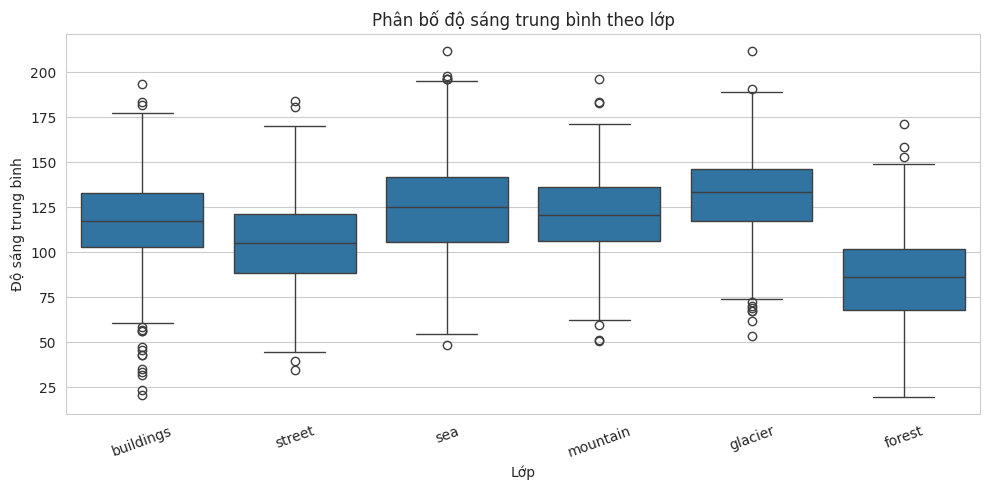

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

brightness_sample = df_train.sample(n=min(2000, len(df_train)), random_state=42).copy()
brightness_sample["brightness"] = brightness_sample["file_path"].progress_apply(average_brightness)

plt.figure(figsize=(10, 5))
sns.boxplot(data=brightness_sample, x="label", y="brightness")
plt.title("Phân bố độ sáng trung bình theo lớp")
plt.xlabel("Lớp")
plt.ylabel("Độ sáng trung bình")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()